A (TD) = 
 [[-2.  1.  0. ...  0.  0.  0.]
 [ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]
 [ 0.  0.  0. ...  0.  1. -2.]]
(50, 50)
0.9903921568627448
1.0


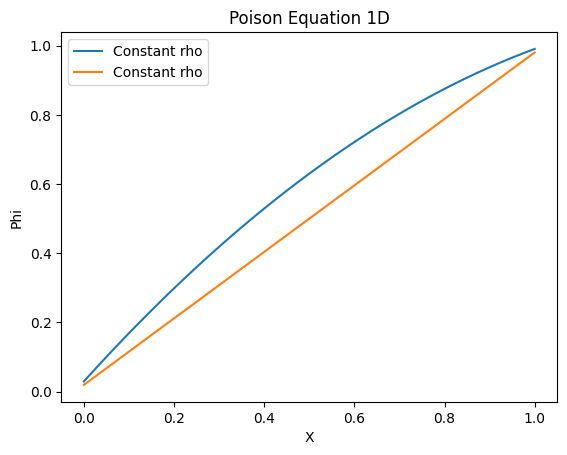

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

# Problem parameters
x0 = 0.0
xf = 1.0
N = 50

x_arr = np.linspace(x0, xf, N)

phi_0 = 0.0
phi_1 = 1.0

epsilon = 1.0
rho_constant = 1.0

# Calculate grid spacing and number of points
h = (xf - x0) / N
n = N - 0
# n = 10

TD = np.zeros((n,n))
for i in range(n):
    TD[i,i] = -2
    if i == n-1:
        TD[i, i-1] = 1
    elif i == 0:
        TD[i, i+1] = 1
    else:
        TD[i, i-1], TD[i, i+1] = 1, 1

print("A (TD) = \n", TD)
print(TD.shape)

# Case 1: rho = constant
B1 = []
for i in range(n):
    x = (i + 1) * h
    rho = rho_constant
    value = -(h * h * rho) / epsilon
    B1.append(value)

B1[0] = B1[0] - phi_0
B1[n-1] = B1[n-1] - phi_1


# Case 2: rho = 0
B2 = []
for i in range(n):
    x = (i + 1) * h
    rho = 0.0
    value = -(h * h * rho) / epsilon
    B2.append(value)

B2[0] = B2[0] - phi_0
B2[n-1] = B2[n-1] - phi_1

def gaussian_elimination(A, B):
    n = len(B)
    A = A.copy()
    B = B.copy()
    
    # Forward elimination
    for i in range(n):
        # Partial pivoting
        max_row = i
        for k in range(i+1, n):
            if abs(A[k][i]) > abs(A[max_row][i]):
                max_row = k
        
        # Swap rows properly
        temp_row = A[i].copy()
        A[i] = A[max_row]
        A[max_row] = temp_row
        
        temp_b = B[i]
        B[i] = B[max_row]
        B[max_row] = temp_b
        
        # Eliminate below
        for k in range(i+1, n):
            factor = A[k][i] / A[i][i]
            for j in range(i, n):
                A[k][j] = A[k][j] - factor * A[i][j]
            B[k] = B[k] - factor * B[i]
    
    # Back substitution
    X = [0.0] * n
    
    for i in range(n-1, -1, -1):
        temp_sum = B[i]
        for j in range(i+1, n):
            temp_sum = temp_sum - A[i][j] * X[j]
        X[i] = float(temp_sum / A[i][i])
    
    return X


phi1 = gaussian_elimination(TD, B1)
phi2 = gaussian_elimination(TD, B2)
print(max(phi1))
print(phi_1)
plt.title("Poison Equation 1D")
plt.xlabel("X")
plt.ylabel("Phi")
plt.plot(x_arr, phi1, label = "Constant rho")
plt.plot(x_arr, phi2, label = "Constant rho")
plt.legend()